In [53]:
import pickle
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import tiktoken
import torch
from matplotlib.ticker import MaxNLocator
from prediction_analysis import f1_score
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from utils import extract_digits_from_answers, merge_with_indomain_year_only

# Investigate where F1 is an unfaithful evaluation

F1 operates on token-level. Therefore, we can have **false positives**, i.e., F1 scores larger than 0 although the overlap in strings is only on tokens that are irrelevant, e.g., expected could be "5 years" and predicted "700 years". Half the token match but the answer is very wrong. We can also have **false negatives** because the time representation is different and all tokens differ. The F1 score would be 0 for this example but temporally, they are the same: "one year" and "12 months". 

## Measure drop of F1 when correcting false positives

Let us identify examples where the digits don't match, e.g. "3 years" and "5 years". These don't have an F1 score of 0 but fail to answer the most important part: the digits representing the number of years. 

### GPT4

In [2]:
df = pd.read_csv(
    "../../models/predictions/gpt4/fewshot_with_reasoning/indomain_eval_gpt_4_few_shot_with_reasoning_single.csv"
)  # .drop(columns="table")
df = df.pipe(merge_with_indomain_year_only).pipe(extract_digits_from_answers)
df.head()

,question,answer,table_id,predicted_answer,predicted_answer_old,predicted_answer_wo_reas,answer_digits,predicted_answer_digits
0,How many years did Art Carney as actor since 1...,54 Years,2,54 years,54 years && Art Carney was active from 1939 to...,54 years,[54],[54]
1,How many total years was Art Carney married to...,28 years,2,45 years,45 years && Art Carney was married to Jean Mye...,45 years,[28],[45]
2,How many years before he died was Art Carney m...,23,2,23 years,23 years && Art Carney remarried his first wif...,23 years,[23],[23]
3,How old was Art Carney when he first got divor...,47,2,46 years old,46 years old && Art was born in 1918 and got d...,46 years old,[47],[46]
4,How many years ago did Art Carney was died?,19 Years ago,2,19 years ago,"19 years ago && Art Carney died in 2003, and c...",19 years ago,[19],[19]


In [3]:
df_pred_single_digit = df.query(
    "answer_digits.str.len()==1 and predicted_answer_digits.str.len()==1"
).copy()
df_pred_single_digit.head()

,question,answer,table_id,predicted_answer,predicted_answer_old,predicted_answer_wo_reas,answer_digits,predicted_answer_digits
0,How many years did Art Carney as actor since 1...,54 Years,2,54 years,54 years && Art Carney was active from 1939 to...,54 years,[54],[54]
1,How many total years was Art Carney married to...,28 years,2,45 years,45 years && Art Carney was married to Jean Mye...,45 years,[28],[45]
2,How many years before he died was Art Carney m...,23,2,23 years,23 years && Art Carney remarried his first wif...,23 years,[23],[23]
3,How old was Art Carney when he first got divor...,47,2,46 years old,46 years old && Art was born in 1918 and got d...,46 years old,[47],[46]
4,How many years ago did Art Carney was died?,19 Years ago,2,19 years ago,"19 years ago && Art Carney died in 2003, and c...",19 years ago,[19],[19]


In [4]:
def calc_f1_fp(df):
    df.loc[:, "F1"] = df.apply(lambda row: f1_score(row["answer"], row["predicted_answer"]), axis=1)
    df.loc[:, "digit_binary"] = df.loc[:, "answer_digits"] == df.loc[:, "predicted_answer_digits"]
    df.loc[:, "F1_corrected"] = df.loc[:, "F1"]
    df.loc[df.loc[:, "digit_binary"] == False, "F1_corrected"] = 0  # noqa: E712


In [5]:
f1_gpt4 = calc_f1_fp(df_pred_single_digit)

In [6]:
f1_gpt4 = df_pred_single_digit.F1.mean()
round(f1_gpt4, 2)

0.69

In [7]:
f1_gpt4_corr = df_pred_single_digit.loc[:, "F1_corrected"].mean()
round(f1_gpt4_corr, 2)

0.63

In [8]:
round(f1_gpt4 - f1_gpt4_corr, 2)

0.06

### PaLM 2

In [9]:
palm = pd.read_csv(
    "../../models/predictions/PaLM/fewshot_with_reasoning/indomain_eval_palm_few_shot_with_reasoning.csv"
).drop(columns="Unnamed: 0")
palm = palm.pipe(merge_with_indomain_year_only).pipe(extract_digits_from_answers)
palm_pred_single_digit = palm.query(
    "answer_digits.str.len()==1 and predicted_answer_digits.str.len()==1"
).copy()
palm_pred_single_digit.head()

,question,answer,table_id,predicted_answer,predicted_answer_old,predicted_answer_wo_reas,answer_digits,predicted_answer_digits
0,How many years did Art Carney as actor since 1...,54 Years,2,54 years,54 years && Carney started acting in 1939 and ...,54 years,[54],[54]
1,How many total years was Art Carney married to...,28 years,2,25 years,25 years && 1965 - 1940,25 years,[28],[25]
2,How many years before he died was Art Carney m...,23,2,6,6 && 1993 - 1980 = 6,6,[23],[6]
3,How old was Art Carney when he first got divor...,47,2,47 years old,47 years old && 1965 - 1918 = 47,47 years old,[47],[47]
4,How many years ago did Art Carney was died?,19 Years ago,2,19 years,19 years && 2022 - 2003,19 years,[19],[19]


In [10]:
palm_pred_single_digit.loc[:, "F1"] = palm_pred_single_digit.apply(
    lambda row: f1_score(row["answer"], row["predicted_answer"]), axis=1
)
f1_palm = calc_f1_fp(palm_pred_single_digit)

In [11]:
f1_palm = palm_pred_single_digit.F1.mean()
round(f1_palm, 2)

0.66

In [12]:
f1_palm_corr = palm_pred_single_digit.loc[:, "F1_corrected"].mean()
round(f1_palm_corr, 2)

0.6

In [13]:
round(f1_palm - f1_palm_corr, 2)

0.05

### Llama 2

In [14]:
llama = pd.read_csv(
    "../../models/predictions/Llama/fewshot_with_reasoning/outdomain_eval_llama2_few_shot_with_reasoning.csv"
).drop(columns="Unnamed: 0")
llama = merge_with_indomain_year_only(llama)
llama = extract_digits_from_answers(llama, split_str_reas="\n\n")
llama_pred_single_digit = llama.query(
    "answer_digits.str.len()==1 and predicted_answer_digits.str.len()==1"
).copy()
llama_pred_single_digit.head()

,question,answer,table_id,predicted_answer,predicted_answer_old,predicted_answer_wo_reas,answer_digits,predicted_answer_digits
0,How many years did Art Carney as actor since 1...,54 Years,2,Answer: 54 years,Answer: 54 years\n\nReasoning: Art Carney beg...,Answer: 54 years,[54],[54]
1,How many total years was Art Carney married to...,28 years,2,Answer: 25 years,Answer: 25 years\n\nReasoning: Art Carney was...,Answer: 25 years,[28],[25]
2,How many years before he died was Art Carney m...,23,2,Answer: 17 years,Answer: 17 years\n\nReasoning: Art Carney die...,Answer: 17 years,[23],[17]
3,How old was Art Carney when he first got divor...,47,2,Answer: 47 years old,Answer: 47 years old\n\nReasoning: Art Carney ...,Answer: 47 years old,[47],[47]
4,How many years ago did Art Carney was died?,19 Years ago,2,Answer: 19 years ago,Answer: 19 years ago\n\nReasoning: Art Carney...,Answer: 19 years ago,[19],[19]


In [15]:
f1_llama = calc_f1_fp(llama_pred_single_digit)

In [16]:
f1_llama = llama_pred_single_digit.F1.mean()
round(f1_llama, 2)


0.37

In [17]:
llama_pred_single_digit.loc[:, "F1_corrected"] = llama_pred_single_digit.loc[:, "F1"]
llama_pred_single_digit.loc[
    llama_pred_single_digit.loc[:, "digit_binary"] == False, "F1_corrected"  # noqa: E712
] = 0
f1_llama_corr = llama_pred_single_digit.loc[:, "F1_corrected"].mean()
round(f1_llama_corr, 2)

0.3

In [18]:
round(f1_llama - f1_llama_corr, 2)

0.07

## Investigate false negatives
Let us identify examples where the F1 score is 0 because expected and predicted answer don't match, e.g. "1 year" and "12 months" but temporally, they are the same.

### Predictions without digits

In [19]:
df.query("predicted_answer_digits.str.len()<1")

,question,answer,table_id,predicted_answer,predicted_answer_old,predicted_answer_wo_reas,answer_digits,predicted_answer_digits
7,How old was Cumberbatch when his career began?,22,3,haa,haa,haa,[22],[]
35,How much longer was Zidane's senior career tha...,9 years,40,haa,haa,haa,[9],[]
36,How long after playing for Real Madrid did Zid...,7 years,40,haa,haa,haa,[7],[]
43,How old was Roy Emerson when he retired from p...,47 years old,50,haa,haa,haa,[47],[]
49,How long did Roy Emerson play professionally?,15 years,50,haa,haa,haa,[15],[]
52,When was the first time that Jack Nicklaus won...,1963,66,haa,haa,haa,[1963],[]
54,How many years had Jack Nicklaus been playing ...,2 years,66,haa,haa,haa,[2],[]
57,How many years before Diegel died was the pict...,19,68,haa,haa,haa,[19],[]
58,How long was Leo Diegel married?,17 years,68,haa,haa,haa,[17],[]
66,How long after starting his pro career did Sne...,8 years,70,haa,haa,haa,[8],[]


In [20]:
df.query("predicted_answer_digits.str.len()<1").apply(
    lambda row: f1_score(row["answer"], row["predicted_answer"]), axis=1
).unique()

array([0])

In [21]:
df.loc[:, "F1"] = df.apply(lambda row: f1_score(row["answer"], row["predicted_answer"]), axis=1)

In [22]:
df.query("predicted_answer_digits.str.len()<1").F1.mean()

0.0

### Predictions with more digits

In [23]:
df_pred_mult_digit = df.query("predicted_answer_digits.str.len()>1").copy()
df_pred_mult_digit.head()

,question,answer,table_id,predicted_answer,predicted_answer_old,predicted_answer_wo_reas,answer_digits,predicted_answer_digits,F1
95,What years did Carolina Albuquerque win medals...,"1999, 2005, 2006, 2008",93,2005 and 2006,2005 and 2006 && Carolina won gold medals in t...,2005 and 2006,"[1999, 2005, 2006, 2008]","[2005, 2006]",0.000000
134,How many years passed between first flight and...,4 years,229,3 years and 7 months,3 years and 7 months && First flight was on 25...,3 years and 7 months,[4],"[3, 7]",0.285714
140,In how many years did Human Development Index ...,1 year,243,0.089 points growth,0.089 points growth && There is no mention of ...,0.089 points growth,[1],"[0, 089]",0.000000
322,How many years ago did Mars Express did Orbita...,9 Years ago,452,"18 years, 6 months, and 7 days ago","18 years, 6 months, and 7 days ago && Mars Exp...","18 years, 6 months, and 7 days ago",[9],"[18, 6, 7]",0.181818
323,"Rounding up, what was the difference in planne...",4 years.,457,"5 years, 6 months","5 years, 6 months && Orbiter planned duration ...","5 years, 6 months",[4],"[5, 6]",0.000000


In [24]:
df_pred_mult_digit.loc[:, "F1"] = df_pred_mult_digit.apply(
    lambda row: f1_score(row["answer"], row["predicted_answer"]), axis=1
)
df_pred_mult_digit.loc[:, ["answer", "predicted_answer", "F1"]]

,answer,predicted_answer,F1
95,"1999, 2005, 2006, 2008",2005 and 2006,0.000000
134,4 years,3 years and 7 months,0.285714
140,1 year,0.089 points growth,0.000000
322,9 Years ago,"18 years, 6 months, and 7 days ago",0.181818
323,4 years.,"5 years, 6 months",0.000000
324,5,4.5 years,0.000000
471,1980,23 July 1977,0.000000
480,"2007, 2008, 2013, 2014","2002, 2007, 2008, and 2014",0.666667
490,"1974, 1975, 1976",1973 and 1975,0.000000
521,1961,"November 10, 1961",0.500000


## Number distribution of wrong predictions 

It looked odd from looking at the above dataframe where predictions had more digits than the expected answer. 

### GPT-4

In [25]:
num_dist = pd.read_csv(
    "../../models/predictions/gpt4/fewshot_with_reasoning/indomain_eval_gpt_4_few_shot_with_reasoning_single.csv"
)

In [26]:
num_dist = num_dist.pipe(merge_with_indomain_year_only).pipe(extract_digits_from_answers)

In [27]:
num_dist.loc[:, ["answer_digits", "predicted_answer_digits"]]

,answer_digits,predicted_answer_digits
0,[54],[54]
1,[28],[45]
2,[23],[23]
3,[47],[46]
4,[19],[19]
...,...,...
853,[16],[16]
854,[1965],[1965]
855,[31],[31]
856,[2],[2]


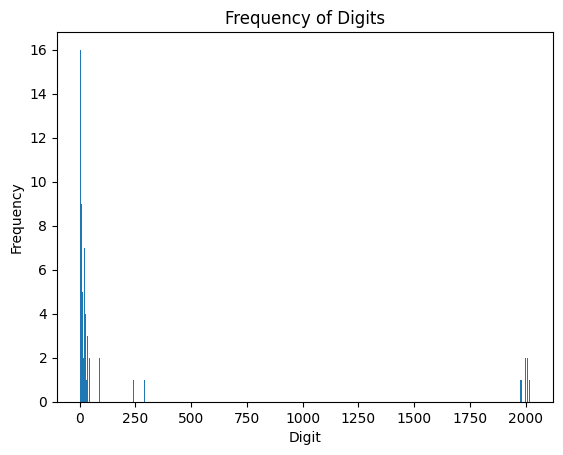

In [28]:
answer_digits = num_dist.loc[:, "answer_digits"].values
pred_digits = num_dist.loc[:, "predicted_answer_digits"].values

filtered_pred_digits = []

for ans, pred in zip(answer_digits, pred_digits):
    answer_digits_counter = Counter(int(i) for i in ans)
    pred_digits_counter = Counter(int(i) for i in pred)
    pred_digits_counter.subtract(answer_digits_counter)
    filtered_pred_digits.extend(list(pred_digits_counter.elements()))


digit_counts = Counter(filtered_pred_digits)
sorted_digits = sorted(digit_counts.keys())

# Prepare data for plotting
x_vals = sorted_digits
y_vals = [digit_counts[d] for d in sorted_digits]

# Plot a bar chart
plt.bar(x_vals, y_vals)
# plt.xlim(0, max(y_vals))
# Labeling
plt.xlabel("Digit")
plt.ylabel("Frequency")
plt.title("Frequency of Digits")

# Display the plot
plt.show()

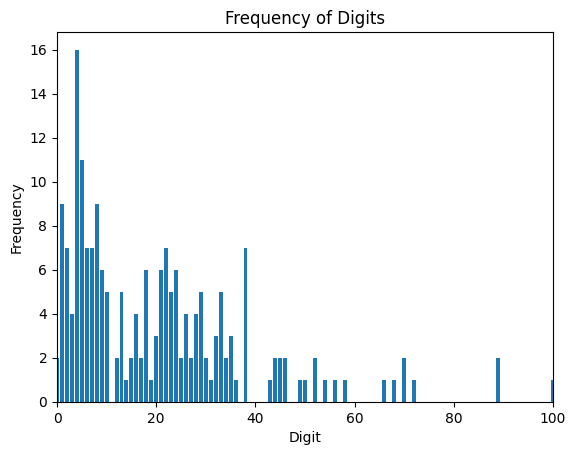

In [29]:
# Plot a bar chart
plt.bar(x_vals, y_vals)
plt.xlim(0, 100)
# Labeling
plt.xlabel("Digit")
plt.ylabel("Frequency")
plt.title("Frequency of Digits")

# Display the plot
plt.show()

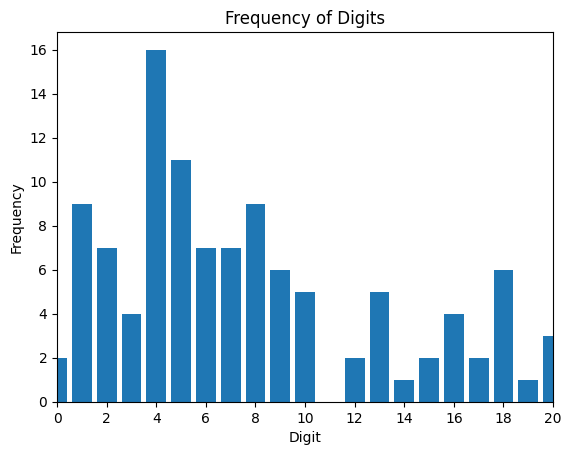

In [30]:
f, ax = plt.subplots()
ax.bar(x_vals, y_vals)
ax.set_xlim(0, 20)

# Labeling
ax.set_xlabel("Digit")
ax.set_ylabel("Frequency")
ax.set_title("Frequency of Digits")

# Display the plot
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show();

In [31]:
num_dist = num_dist.assign(
    predicted_answer_digits=lambda x: x["predicted_answer_digits"].apply(
        lambda y: [int(i) for i in y]
    ),
    answer_digits=lambda x: x["answer_digits"].apply(lambda y: [int(i) for i in y]),
)

In [32]:
pred_contains_4 = [4 in i for i in num_dist["predicted_answer_digits"].values]
num_dist_4s = num_dist.loc[pred_contains_4]
num_dist_4s.head()

,question,answer,table_id,predicted_answer,predicted_answer_old,predicted_answer_wo_reas,answer_digits,predicted_answer_digits
20,how many years Joan Crawford and Franchot Tone...,4,8,4 years,4 years && They were married in 1935 and divor...,4 years,[4],[4]
73,How many years longer did Manning play for the...,11,75,4 years longer,4 years longer && Eli played for Ole Miss from...,4 years longer,[11],[4]
77,How many years did Eli Manning attend school a...,4 years,75,4 years,4 years && Eli Manning attended Ole Miss from ...,4 years,[4],[4]
97,How many years separate the two gold medals th...,4 years,96,4 years,4 years && Thiago Alves won gold in 2009 and 2...,4 years,[4],[4]
135,How many years did JF-17 Thunder was introduce...,4 Years after,229,4 years,4 years && JF-17 Thunder was introduced in 200...,4 years,[4],[4]


In [33]:
answer_not_contains_4 = [4 not in i for i in num_dist_4s["answer_digits"].values]
num_dist_4s.loc[answer_not_contains_4]

,question,answer,table_id,predicted_answer,predicted_answer_old,predicted_answer_wo_reas,answer_digits,predicted_answer_digits
73,How many years longer did Manning play for the...,11,75,4 years longer,4 years longer && Eli played for Ole Miss from...,4 years longer,[11],[4]
295,How many years longer did Young play for the N...,2,401,4 years,4 years && Young played for the Giants for (19...,4 years,[2],[4]
304,For how many years did Benny McCoy play profes...,3,405,4 years,4 years && Benny McCoy played from 1938 to 1941.,4 years,[3],[4]
305,How many total years did Benny McCoy for MLB?,3 years,405,4 years,4 years && Benny played for Detroit Tigers (19...,4 years,[3],[4]
324,How many years longer is the orbiter's planned...,5,457,4.5 years,4.5 years && The orbiter's planned mission dur...,4.5 years,[5],"[4, 5]"
356,How many years longer did Hasanefendić manage ...,3,503,4 years,4 years && He managed Switzerland from 1980-19...,4 years,[3],[4]
394,How many years did Dennis Erickson worked as H...,3 Years,540,4 years,4 years && Erickson worked as head coach for I...,4 years,[3],[4]
426,How much longer did Hewitt's NBA career last t...,2 years,568,4 years longer,4 years longer && Hewitt's college career last...,4 years longer,[2],[4]
428,How much longer was Hosket's NBA career than h...,1 year,569,4 years,4 years && Hosket's NBA career was from 1968-1...,4 years,[1],[4]
549,At what age did Gorshkovabegin skating?,5 years old,743,4 years old,4 years old && Gorshkova began skating in 1993...,4 years old,[5],[4]


### PaLM 2

In [34]:
num_dist = pd.read_csv(
    "../../models/predictions/PaLM/fewshot_with_reasoning/indomain_eval_palm_few_shot_with_reasoning.csv"
).drop(columns=["Unnamed: 0"])
num_dist.head()

,table,question,predicted_answer,actual_answer
0,2,How many years did Art Carney as actor since 1...,54 years && Carney started acting in 1939 and ...,54 Years
1,2,Who was the spouse of Art Carney in 1970?,Barbara Isaac && The passage states that Art C...,Barbara Isaac
2,2,How many total years was Art Carney married to...,25 years && 1965 - 1940,28 years
3,2,Which spouse was Art Carney married to the least?,Barbara Isaac && Barbara Isaac was married to ...,Barbara Isaac
4,2,Who was Art Carney married to when he served i...,Jean Myers && He was married to Jean Myers fro...,Jean Myers


In [35]:
num_dist = num_dist.pipe(merge_with_indomain_year_only).pipe(extract_digits_from_answers)
num_dist.head()

,question,answer,table_id,predicted_answer,predicted_answer_old,predicted_answer_wo_reas,answer_digits,predicted_answer_digits
0,How many years did Art Carney as actor since 1...,54 Years,2,54 years,54 years && Carney started acting in 1939 and ...,54 years,[54],[54]
1,How many total years was Art Carney married to...,28 years,2,25 years,25 years && 1965 - 1940,25 years,[28],[25]
2,How many years before he died was Art Carney m...,23,2,6,6 && 1993 - 1980 = 6,6,[23],[6]
3,How old was Art Carney when he first got divor...,47,2,47 years old,47 years old && 1965 - 1918 = 47,47 years old,[47],[47]
4,How many years ago did Art Carney was died?,19 Years ago,2,19 years,19 years && 2022 - 2003,19 years,[19],[19]


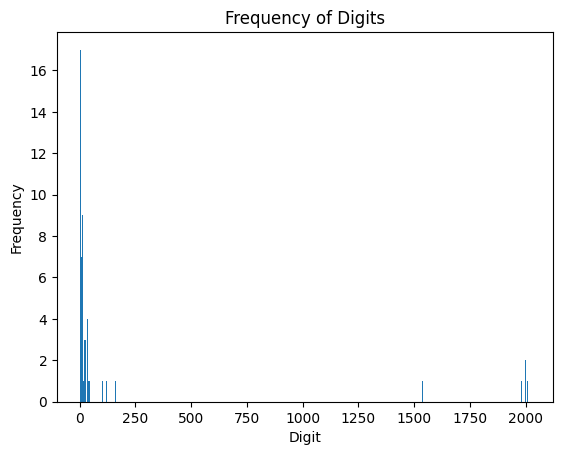

In [36]:
answer_digits = num_dist.loc[:, "answer_digits"].values
pred_digits = num_dist.loc[:, "predicted_answer_digits"].values

filtered_pred_digits = []

for ans, pred in zip(answer_digits, pred_digits):
    answer_digits_counter = Counter(int(i) for i in ans)
    pred_digits_counter = Counter(int(i) for i in pred)
    pred_digits_counter.subtract(answer_digits_counter)
    filtered_pred_digits.extend(list(pred_digits_counter.elements()))


digit_counts = Counter(filtered_pred_digits)
sorted_digits = sorted(digit_counts.keys())

# Prepare data for plotting
x_vals = sorted_digits
y_vals = [digit_counts[d] for d in sorted_digits]

# Plot a bar chart
plt.bar(x_vals, y_vals)
# plt.xlim(0, max(y_vals))
# Labeling
plt.xlabel("Digit")
plt.ylabel("Frequency")
plt.title("Frequency of Digits")

# Display the plot
plt.show()

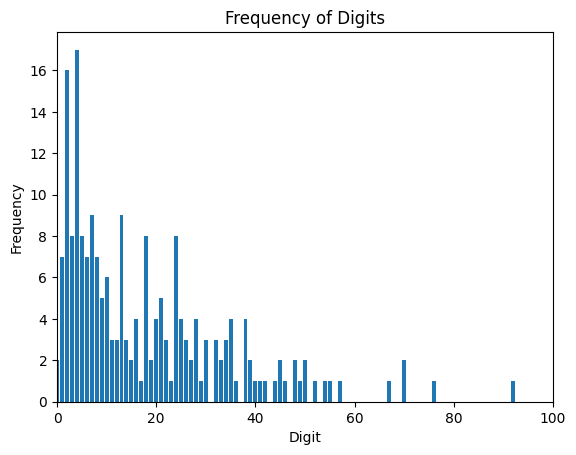

In [37]:
# Plot a bar chart
plt.bar(x_vals, y_vals)
plt.xlim(0, 100)
# Labeling
plt.xlabel("Digit")
plt.ylabel("Frequency")
plt.title("Frequency of Digits")

# Display the plot
plt.show()

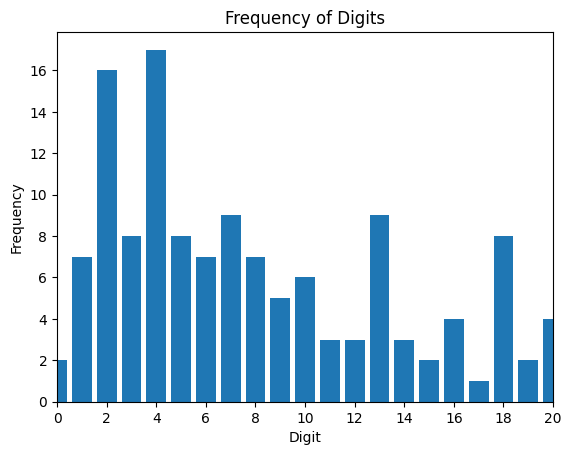

In [38]:
f, ax = plt.subplots()
ax.bar(x_vals, y_vals)
ax.set_xlim(0, 20)

# Labeling
ax.set_xlabel("Digit")
ax.set_ylabel("Frequency")
ax.set_title("Frequency of Digits")

# Display the plot
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show();

In [39]:
num_dist = num_dist.assign(
    predicted_answer_digits=lambda x: x["predicted_answer_digits"].apply(
        lambda y: [int(i) for i in y]
    ),
    answer_digits=lambda x: x["answer_digits"].apply(lambda y: [int(i) for i in y]),
)

In [40]:
pred_contains_4 = [4 in i for i in num_dist["predicted_answer_digits"].values]
num_dist_4s = num_dist.loc[pred_contains_4]
num_dist_4s

,question,answer,table_id,predicted_answer,predicted_answer_old,predicted_answer_wo_reas,answer_digits,predicted_answer_digits
6,How many years prior to Cumberbatch turning 45...,2,3,4,4 && Benedict Cumberbatch was born in 1976 and...,4,[2],[4]
20,how many years Joan Crawford and Franchot Tone...,4,8,4 years,4 years && 1935 - 1939,4 years,[4],[4]
31,How long after the constitution was adopted wa...,44 years,22,4 years,4 years && 1974 - 1970,4 years,[44],[4]
77,How many years did Eli Manning attend school a...,4 years,75,4,4 && Eli Manning attended Ole Miss from 1999 -...,4,[4],[4]
97,How many years separate the two gold medals th...,4 years,96,4 years,4 years && Alves won the first gold medal in t...,4 years,[4],[4]
100,How many years after winning his first medal i...,8,115,4,4 && Biondi won his first medal in 1984 and hi...,4,[8],[4]
111,How much longer was Peter III's reign as King ...,6 years,122,4 years,4 years && Peter III reigned as King of Aragon...,4 years,[6],[4]
134,How many years passed between first flight and...,4 years,229,4,4 && 2007 - 2003 = 4 years.,4,[4],[4]
135,How many years did JF-17 Thunder was introduce...,4 Years after,229,4,4 && 2007 - 2003 = 4,4,[4],[4]
138,How many years after its first flight was the ...,4,229,4,4 && First flight 2003 and produced in Pakista...,4,[4],[4]


In [41]:
answer_not_contains_4 = [4 not in i for i in num_dist_4s["answer_digits"].values]
num_dist_4s.loc[answer_not_contains_4]

,question,answer,table_id,predicted_answer,predicted_answer_old,predicted_answer_wo_reas,answer_digits,predicted_answer_digits
6,How many years prior to Cumberbatch turning 45...,2,3,4,4 && Benedict Cumberbatch was born in 1976 and...,4,[2],[4]
31,How long after the constitution was adopted wa...,44 years,22,4 years,4 years && 1974 - 1970,4 years,[44],[4]
100,How many years after winning his first medal i...,8,115,4,4 && Biondi won his first medal in 1984 and hi...,4,[8],[4]
111,How much longer was Peter III's reign as King ...,6 years,122,4 years,4 years && Peter III reigned as King of Aragon...,4 years,[6],[4]
287,How many years between his first award and las...,26,370,4,4,4,[26],[4]
292,How many years did Art Wilson play for MLB?,13 years,400,4,4 && The article states that Art Wilson debute...,4,[13],[4]
305,For how many years did Benny McCoy play profes...,3,405,4,"4 && McCoy's debut was September 14, 1938 and ...",4,[3],[4]
306,How many total years did Benny McCoy for MLB?,3 years,405,4,4 && 4 years (1938-1941),4,[3],[4]
396,How many years did Dennis Erickson worked as H...,3 Years,540,4 years,4 years && 1982 - 1985,4 years,[3],[4]
422,How much longer did Smawley coach for Pembroke...,3 years,566,4,4 && 52 - 48,4,[3],[4]


### Does perplexity/logloss predict the biases in numbers?

In [42]:
# Taken from:
# https://github.com/tommccoy1/embers-of-autoregression/blob/5dd6c91ad57cd2d913402b98e4253fda806fbe93/example_generation_scripts/score_cmu_words.py#L14
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
gpt4_enc = tiktoken.get_encoding("cl100k_base")
gpt2_tokenizer = GPT2Tokenizer.from_pretrained("gpt2-xl")
gpt2_model = GPT2LMHeadModel.from_pretrained("gpt2-xl").to(device)


def prob_gpt2(string):
    # Tokenize the sentence
    tokens = gpt2_tokenizer.encode(string)

    targets = tokens[:]

    # Compute average log likelihood for the generation
    input_ids = torch.LongTensor(tokens).to(device)
    target_ids = torch.LongTensor(targets).to(device)

    with torch.no_grad():
        outputs = gpt2_model(input_ids, labels=target_ids)
        log_likelihood = -1 * outputs[0] * (len(input_ids) - 1)

    return log_likelihood.item()


In [43]:
prob_gpt2('The digit is "')

`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


-20.54248809814453

In [44]:
# Get perplexity using GPT-2
def prob_gpt2_word(word):
    # Orignal experiment was with 'The word is"'
    sentence = 'The word is "' + word + '"'
    log_likelihood = prob_gpt2(sentence)
    return log_likelihood + 20.54248809814453



In [45]:
2**(-prob_gpt2_word("1"))

11.925700626894063

In [46]:
losses = []

for i in range(2000):
    losses.append(prob_gpt2_word(str(i)))

In [50]:
digit_to_loss = dict(zip(range(2000), losses))

In [57]:
with open("data/notebook_output/05_gpt2_logloss_per_digit.pickle", "wb") as f:
    pickle.dump(digit_to_loss, f)

In [58]:
with open("data/notebook_output/05_gpt2_logloss_per_digit.pickle", "rb") as f:
    digit_to_loss = pickle.load(f)

In [60]:
sorted(digit_to_loss.items(), key=lambda x: x[1], reverse=True)[:15]

[(1, -3.5760021209716797),
 (0, -3.852090835571289),
 (100, -4.204862594604492),
 (5, -4.280239105224609),
 (7, -4.284172058105469),
 (2, -4.334873199462891),
 (6, -4.383602142333984),
 (12, -4.424333572387695),
 (9, -4.430324554443359),
 (8, -4.495426177978516),
 (10, -4.531728744506836),
 (4, -4.572870254516602),
 (3, -4.658229827880859),
 (24, -4.8067626953125),
 (666, -4.81633186340332)]

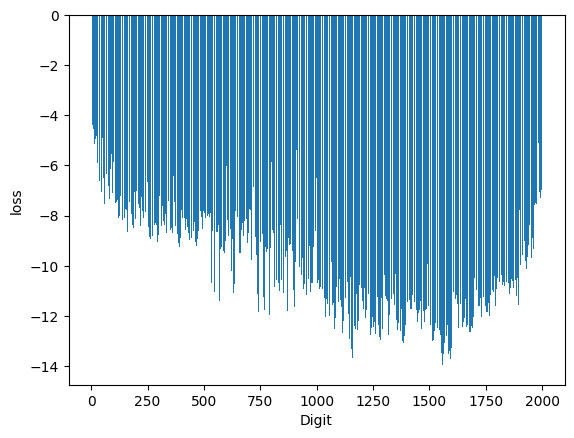

In [47]:
plt.bar(range(2000), losses)

plt.xlabel("Digit")
plt.ylabel("loss")

# Display the plot
plt.show()

In [48]:
digit_to_loss = dict(zip(range(2000), [2**(-i) for i in losses]))
sorted(digit_to_loss.items(), key=lambda x: x[1], reverse=False)[:15]

[(1, 11.925700626894063),
 (0, 14.440920846101081),
 (100, 18.441225082982488),
 (5, 19.430338172756983),
 (7, 19.483379778918657),
 (2, 20.18026479092547),
 (6, 20.873521996247685),
 (12, 21.47123949171825),
 (9, 21.56058704016006),
 (8, 22.555794171489826),
 (10, 23.13056729504896),
 (4, 23.799679732866064),
 (3, 25.250321077872215),
 (24, 27.988508350462766),
 (666, 28.174768735849515)]

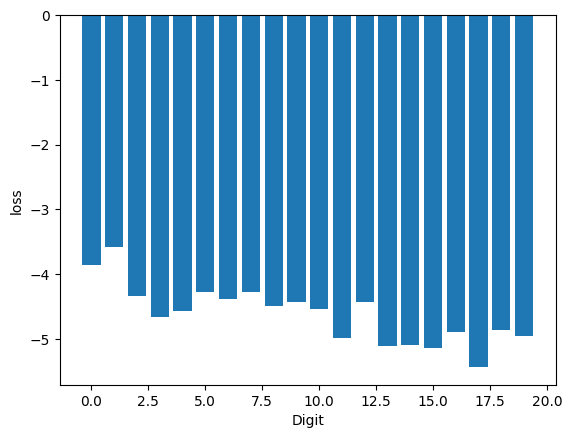

In [49]:
plt.bar(range(20), losses[:20])

plt.xlabel("Digit")
plt.ylabel("loss")

# Display the plot
plt.show()